# Swimming Pool Lane Line Detection using YOLO26n-seg

This notebook trains and evaluates a YOLO26n-seg segmentation model to detect swimming pool lane lines.

## Model
- YOLO26n-seg (Ultralytics)

## Dataset
- Roboflow dataset *(link to be added)*

The notebook is organized into setup, data loading, training, evaluation, and inference.


## Configuration
Centralized configuration for paths and hyperparameters.

In [ ]:
from pathlib import Path

DATASET_CONFIG='path/to/data.yaml'
MODEL_NAME='yolo26n-seg.pt'
IMAGE_SIZE=640
EPOCHS=100
BATCH_SIZE=16
DEVICE=0
WORKERS=2
PROJECT_NAME='lane-line-detection'
RUN_NAME='baseline'
SEED=42


<a href="https://colab.research.google.com/github/kornranath/PoolDetection/blob/main/pool_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!unzip /content/dataset.zip

Archive:  /content/dataset.zip
 extracting: train/images/images_jpg.rf.62af41152e63084d2563ef9ce9bce8a2.jpg  
 extracting: train/images/images_jpg.rf.1180cbb655b757f5c9a3ea393d1161be.jpg  
 extracting: train/images/images_jpg.rf.53ffb478728415867d49e930ed41f022.jpg  
 extracting: train/images/images_jpg.rf.64b16c078c953580a7ae3cc14dabb333.jpg  
 extracting: train/images/images_jpg.rf.7006d4a1ca642e9ad09f61692f1e936f.jpg  
 extracting: train/images/images_jpg.rf.9a4855ad9233f846986dc502b3c03406.jpg  
 extracting: train/images/images_jpg.rf.223d65c158523e4440db5bf03e4dd77c.jpg  
 extracting: train/images/images_jpg.rf.a8b6791d8c40c0a8247f75c6c8d96a33.jpg  
 extracting: train/images/images_jpg.rf.f9d112addef3502195c3750af02b9241.jpg  
 extracting: train/images/images_jpg.rf.0a9da52cd758eec079e6e1a327d125b9.jpg  
 extracting: train/images/images_jpg.rf.3724464087a1147a216ea023612c17ce.jpg  
 extracting: train/images/images_jpg.rf.70290c9e10b5920f4a72cd944f61621f.jpg  
 extracting: train/im

In [ ]:
!uv pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.8/112.6 GB disk)


In [ ]:
!yolo train model=yolo26n-seg.pt data=data.yaml epochs=100 imgsz=640

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=

In [ ]:
!yolo predict \
model=/content/runs/segment/train/weights/best.pt \
source=/content/povswim1.jpg \
conf=0.25

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,274 parameters, 0 gradients, 9.0 GFLOPs

image 1/1 /content/povswim1.jpg: 640x384 4 lanes, 4 t marks, 71.9ms
Speed: 2.9ms preprocess, 71.9ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/segment/predict-6
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
!yolo segment predict model=/content/best.pt source=/content/povswim1.jpg # predict with custom model

Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,274 parameters, 0 gradients, 9.0 GFLOPs

image 1/1 /content/povswim1.jpg: 640x384 4 lanes, 4 t marks, 66.7ms
Speed: 11.5ms preprocess, 66.7ms inference, 10.2ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/segment/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
results = model.predict(
    source="/content/povswim1.jpg",
    save=True,
    show_boxes=False
)


image 1/1 /content/povswim1.jpg: 640x384 (no detections), 350.7ms
Speed: 2.5ms preprocess, 350.7ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/segment/predict-2


In [11]:
from ultralytics import YOLO

model = YOLO("/content/runs/segment/best.pt")

results = model("/content/povswim1.jpg")

print(results[0].masks)


image 1/1 /content/povswim1.jpg: 640x384 4 lanes, 4 t marks, 25.3ms
Speed: 2.9ms preprocess, 25.3ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 384)
ultralytics.engine.results.Masks object with attributes:

data: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
        

In [14]:
with open("/content/train/labels/images_jpg.rf.00226896c301690d4542badddc428eb1.txt") as f:
    print(f.read())

0 0.3700740740740741 0.7978600823045267 0.32266666666666666 0.8406584362139917 0.1731997913406364 1 0.21556695156695155 1 0.21866666666666668 0.997201646090535 0.2628148148148149 0.9364609053497943 0.3591111111111111 0.828641975308642 0.378962962962963 0.7981893004115226 0.3700740740740741 0.7978600823045267
0 0.5795555555555555 0.997201646090535 0.5555555555555556 0.9562139917695474 0.4897777777777778 0.8067489711934156 0.4811851851851852 0.8019753086419753 0.47482785185185183 0.8086502057613167 0.4942222222222223 0.8737448559670782 0.5380698910675382 1 0.5804747228980806 1 0.5795555555555555 0.997201646090535
0 0.8142222222222223 0.9524279835390946 0.6225185185185187 0.8205761316872427 0.5834074074074075 0.8057613168724279 0.8585345284401602 1 0.8934581728395061 1 0.8142222222222223 0.9524279835390946
0 0.2634074074074074 0.793909465020576 0 0.902942521819956 0 0.9244195087843444 0.23051851851851854 0.8194238683127572 0.26281481481481483 0.802798353909465 0.2634074074074074 0.7939094

In [15]:
from ultralytics import YOLO

model = YOLO("/content/runs/segment/best.pt")

results = model("/content/povswim1.jpg")

print("Boxes:", results[0].boxes)
print("Masks:", results[0].masks)


image 1/1 /content/povswim1.jpg: 640x384 4 lanes, 4 t marks, 11.8ms
Speed: 2.4ms preprocess, 11.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)
Boxes: ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0., 0., 0., 1., 1., 1., 1.], device='cuda:0')
conf: tensor([0.9484, 0.8723, 0.8591, 0.6831, 0.4704, 0.4003, 0.3144, 0.2895], device='cuda:0')
data: tensor([[1.3427e+02, 1.4393e+02, 1.9442e+02, 5.8313e+02, 9.4841e-01, 0.0000e+00],
        [2.3568e+02, 1.4992e+02, 3.3448e+02, 2.5430e+02, 8.7226e-01, 0.0000e+00],
        [6.6401e+01, 1.2044e+02, 1.0211e+02, 1.6673e+02, 8.5912e-01, 0.0000e+00],
        [2.9688e+02, 1.5525e+02, 3.3491e+02, 1.7421e+02, 6.8313e-01, 0.0000e+00],
        [2.1566e+02, 1.4817e+02, 2.5060e+02, 1.5231e+02, 4.7038e-01, 1.0000e+00],
        [2.1512e+02, 1.4787e+02, 2.5084e+02, 1.5172e+02, 4.0030e-01, 1.0000e+00],
        [2.9227e+02, 1.5381e+02, 3.2109e+02, 1.5923e+02, 3.1439e-01, 1.0000e+00],
        [1.2757e+02, 1.4032e+0

In [17]:
from ultralytics import YOLO

model = YOLO("/content/runs/segment/best.pt")

print("Task:", model.task)

results = model("/content/povswim1.jpg")

print("Masks:", results[0].masks)

if results[0].masks is not None:
    print(results[0].masks.xy[0][:10])

Task: segment

image 1/1 /content/povswim1.jpg: 640x384 4 lanes, 4 t marks, 11.6ms
Speed: 1.6ms preprocess, 11.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)
Masks: ultralytics.engine.results.Masks object with attributes:

data: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..


image 1/1 /content/povswim1.jpg: 640x384 4 lanes, 4 t marks, 11.1ms
Speed: 1.6ms preprocess, 11.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)


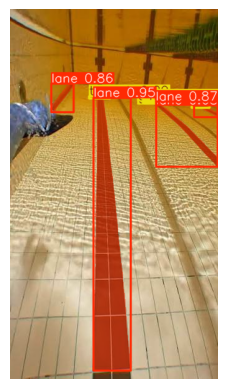

In [23]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("/content/runs/segment/best.pt")

results = model("/content/povswim1.jpg")

img = results[0].plot(
    boxes=True,
    labels=True,
    conf=True
)

plt.imshow(img)
plt.axis("off")
plt.show()


image 1/1 /content/povswim1.jpg: 640x384 4 lanes, 4 t marks, 16.0ms
Speed: 3.6ms preprocess, 16.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 384)


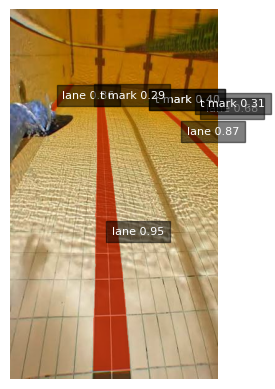

In [25]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("/content/runs/segment/best.pt")
results = model("/content/povswim1.jpg")

img = results[0].plot(boxes=False)

plt.imshow(img)

for box in results[0].boxes:

    cls = int(box.cls.cpu().item())
    conf = float(box.conf.cpu().item())

    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

    x = (x1 + x2) / 2
    y = (y1 + y2) / 2

    plt.text(
        x,
        y,
        f"{results[0].names[cls]} {conf:.2f}",
        color="white",
        fontsize=8,
        bbox=dict(facecolor="black", alpha=0.5)
    )

plt.axis("off")
plt.show()


image 1/1 /content/povswim1.jpg: 640x384 4 lanes, 4 t marks, 13.4ms
Speed: 1.6ms preprocess, 13.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 384)


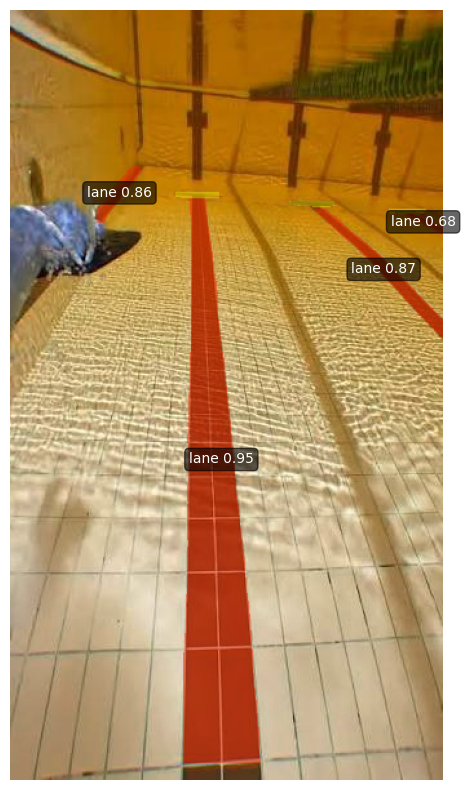

In [26]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

# Load model
model = YOLO("/content/runs/segment/best.pt")

# Run inference
results = model("/content/povswim1.jpg")

# Plot segmentation masks only (no boxes)
img = results[0].plot(
    boxes=False,
    labels=False,
    conf=False
)

# Display image
plt.figure(figsize=(6, 10))
plt.imshow(img)

# Add labels to the center of each lane mask
for i, mask in enumerate(results[0].masks.xy):

    # Get class and confidence
    cls = int(results[0].boxes[i].cls.cpu())
    conf = float(results[0].boxes[i].conf.cpu())

    # Only show labels for lanes
    if results[0].names[cls] != "lane":
        continue

    # Compute centroid of the segmentation mask
    cx = np.mean(mask[:, 0])
    cy = np.mean(mask[:, 1])

    # Draw label
    plt.text(
        cx,
        cy,
        f"{results[0].names[cls]} {conf:.2f}",
        color="white",
        fontsize=10,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="black",
            alpha=0.6,
            boxstyle="round,pad=0.3"
        )
    )

# Remove axes and display
plt.axis("off")
plt.show()


image 1/1 /content/povswim1.jpg: 640x384 4 lanes, 4 t marks, 12.1ms
Speed: 1.6ms preprocess, 12.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)


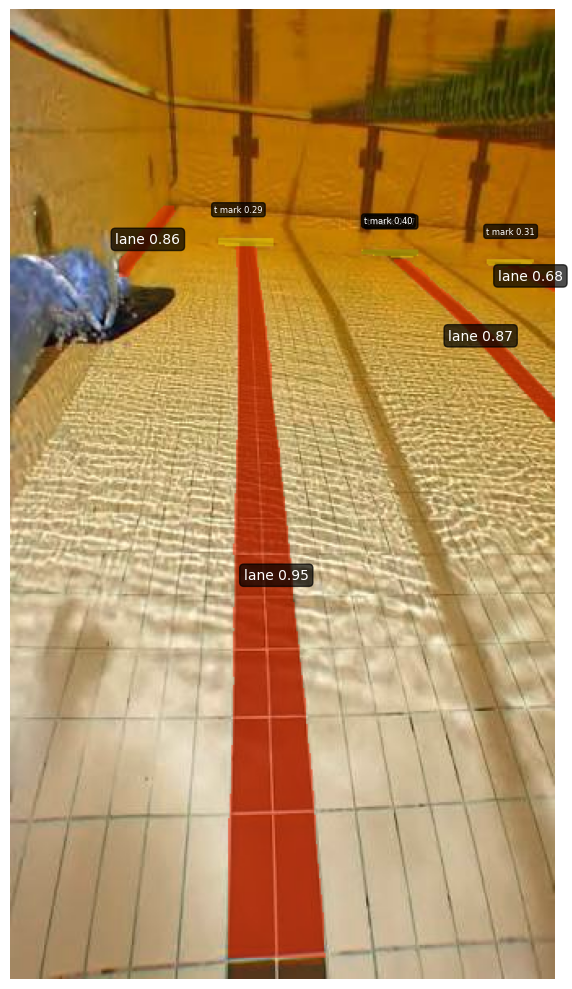

In [27]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

# Load model
model = YOLO("/content/runs/segment/best.pt")

# Run inference
results = model("/content/povswim1.jpg")

# Draw masks only
img = results[0].plot(
    boxes=False,
    labels=False,
    conf=False
)

plt.figure(figsize=(6, 10))
plt.imshow(img)

# Draw custom labels
for i, mask in enumerate(results[0].masks.xy):

    # Get class and confidence
    cls = int(results[0].boxes[i].cls.cpu())
    conf = float(results[0].boxes[i].conf.cpu())
    name = results[0].names[cls]

    # Compute centroid of mask
    cx = np.mean(mask[:, 0])
    cy = np.mean(mask[:, 1])

    # Position and styling
    if name == "lane":
        x = cx
        y = cy
        fontsize = 10
    else:  # t_mark
        x = cx
        y = max(10, cy - 20)   # Move label above mask
        fontsize = 6

    # Draw label
    plt.text(
        x,
        y,
        f"{name} {conf:.2f}",
        color="white",
        fontsize=fontsize,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="black",
            alpha=0.7,
            boxstyle="round,pad=0.3"
        )
    )

plt.axis("off")
plt.tight_layout()
plt.show()

above is the command that works


image 1/1 /content/poolmanylines.jpg: 512x640 8 lanes, 484.4ms
Speed: 4.2ms preprocess, 484.4ms inference, 1.9ms postprocess per image at shape (1, 3, 512, 640)


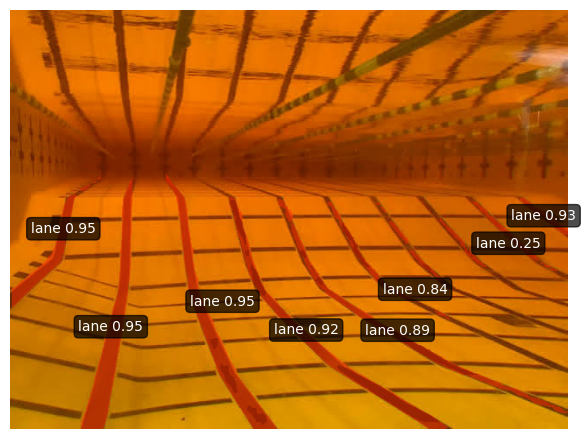

In [28]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

# Load model
model = YOLO("/content/runs/segment/best.pt")

# Run inference
results = model("/content/poolmanylines.jpg")

# Draw masks only
img = results[0].plot(
    boxes=False,
    labels=False,
    conf=False
)

plt.figure(figsize=(6, 10))
plt.imshow(img)

# Draw custom labels
for i, mask in enumerate(results[0].masks.xy):

    # Get class and confidence
    cls = int(results[0].boxes[i].cls.cpu())
    conf = float(results[0].boxes[i].conf.cpu())
    name = results[0].names[cls]

    # Compute centroid of mask
    cx = np.mean(mask[:, 0])
    cy = np.mean(mask[:, 1])

    # Position and styling
    if name == "lane":
        x = cx
        y = cy
        fontsize = 10
    else:  # t_mark
        x = cx
        y = max(10, cy - 20)   # Move label above mask
        fontsize = 6

    # Draw label
    plt.text(
        x,
        y,
        f"{name} {conf:.2f}",
        color="white",
        fontsize=fontsize,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="black",
            alpha=0.7,
            boxstyle="round,pad=0.3"
        )
    )

plt.axis("off")
plt.tight_layout()
plt.show()


image 1/1 /content/povswim2.jpg: 384x640 4 t marks, 390.5ms
Speed: 1.7ms preprocess, 390.5ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


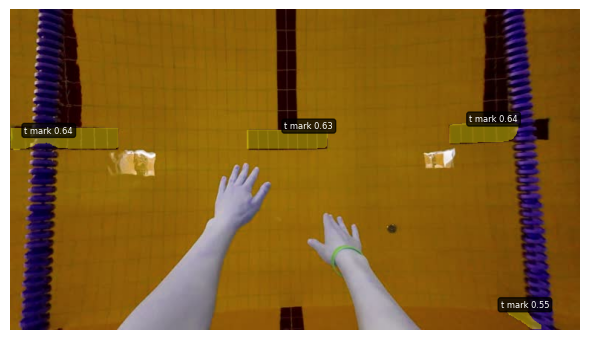

In [29]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

# Load model
model = YOLO("/content/runs/segment/best.pt")

# Run inference
results = model("/content/povswim2.jpg")

# Draw masks only
img = results[0].plot(
    boxes=False,
    labels=False,
    conf=False
)

plt.figure(figsize=(6, 10))
plt.imshow(img)

# Draw custom labels
for i, mask in enumerate(results[0].masks.xy):

    # Get class and confidence
    cls = int(results[0].boxes[i].cls.cpu())
    conf = float(results[0].boxes[i].conf.cpu())
    name = results[0].names[cls]

    # Compute centroid of mask
    cx = np.mean(mask[:, 0])
    cy = np.mean(mask[:, 1])

    # Position and styling
    if name == "lane":
        x = cx
        y = cy
        fontsize = 10
    else:  # t_mark
        x = cx
        y = max(10, cy - 20)   # Move label above mask
        fontsize = 6

    # Draw label
    plt.text(
        x,
        y,
        f"{name} {conf:.2f}",
        color="white",
        fontsize=fontsize,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="black",
            alpha=0.7,
            boxstyle="round,pad=0.3"
        )
    )

plt.axis("off")
plt.tight_layout()
plt.show()